# 01 — EDA: Model Perencana Makan

**Dataset:**
- `nutrition.csv` (1,346 makanan Indonesia) — **primary**
- `diet_recommendations_dataset.csv` (1,000 pasien) — **validation rules**

**Tujuan:**
- Distribusi makro (kalori/protein/karbo/lemak)
- Identifikasi 0-kalori (edge case → impute)
- Analisis nama makanan untuk heuristic kategorisasi
- **Cuisine clustering** (Padang/Jawa/Sunda heuristic) — riset IPB Jurnal 2024
- Distribusi harga per kategori (validasi heuristic pricing)
- Eksplorasi dataset validasi medis (Diabetes/Hypertension)

**Riset acuan:**
- Frontiers Nutrition 2025: GA-based Indonesian restaurant food selection
- IPB Jurnal Keteknikan 2024: Indonesian food recommendation untuk NCD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

sns.set_theme(style='darkgrid')
os.makedirs('output/eda', exist_ok=True)

NUT_PATH  = '../../dataset/Model_Perencana Makan_dan_Nutrisi/Indonesian Food & Drink Nutrition Dataset/nutrition.csv'
DIET_PATH = '../../dataset/Model_Perencana Makan_dan_Nutrisi/Diet Recommendations Dataset/diet_recommendations_dataset.csv'

df = pd.read_csv(NUT_PATH)
print(f'Nutrition dataset: {df.shape}')
df.head()

Nutrition dataset: (1346, 7)


,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


In [2]:
# ── Basic Stats ──
print('Kolom:', list(df.columns))
print('\nMissing values:')
print(df.isnull().sum())
print('\nStatistik:')
df[['calories','proteins','fat','carbohydrate']].describe().round(2)

Kolom: ['id', 'calories', 'proteins', 'fat', 'carbohydrate', 'name', 'image']

Missing values:
id              0
calories        0
proteins        0
fat             0
carbohydrate    0
name            0
image           0
dtype: int64

Statistik:


,calories,proteins,fat,carbohydrate
count,1346.00,1346.00,1346.00,1346.00
mean,203.22,10.00,7.58,25.39
std,163.08,11.85,13.73,32.19
min,0.00,0.00,0.00,0.00
25%,75.00,1.80,0.50,4.53
50%,146.00,5.00,2.00,13.30
75%,333.75,15.00,8.28,37.58
max,940.00,83.00,100.00,647.00


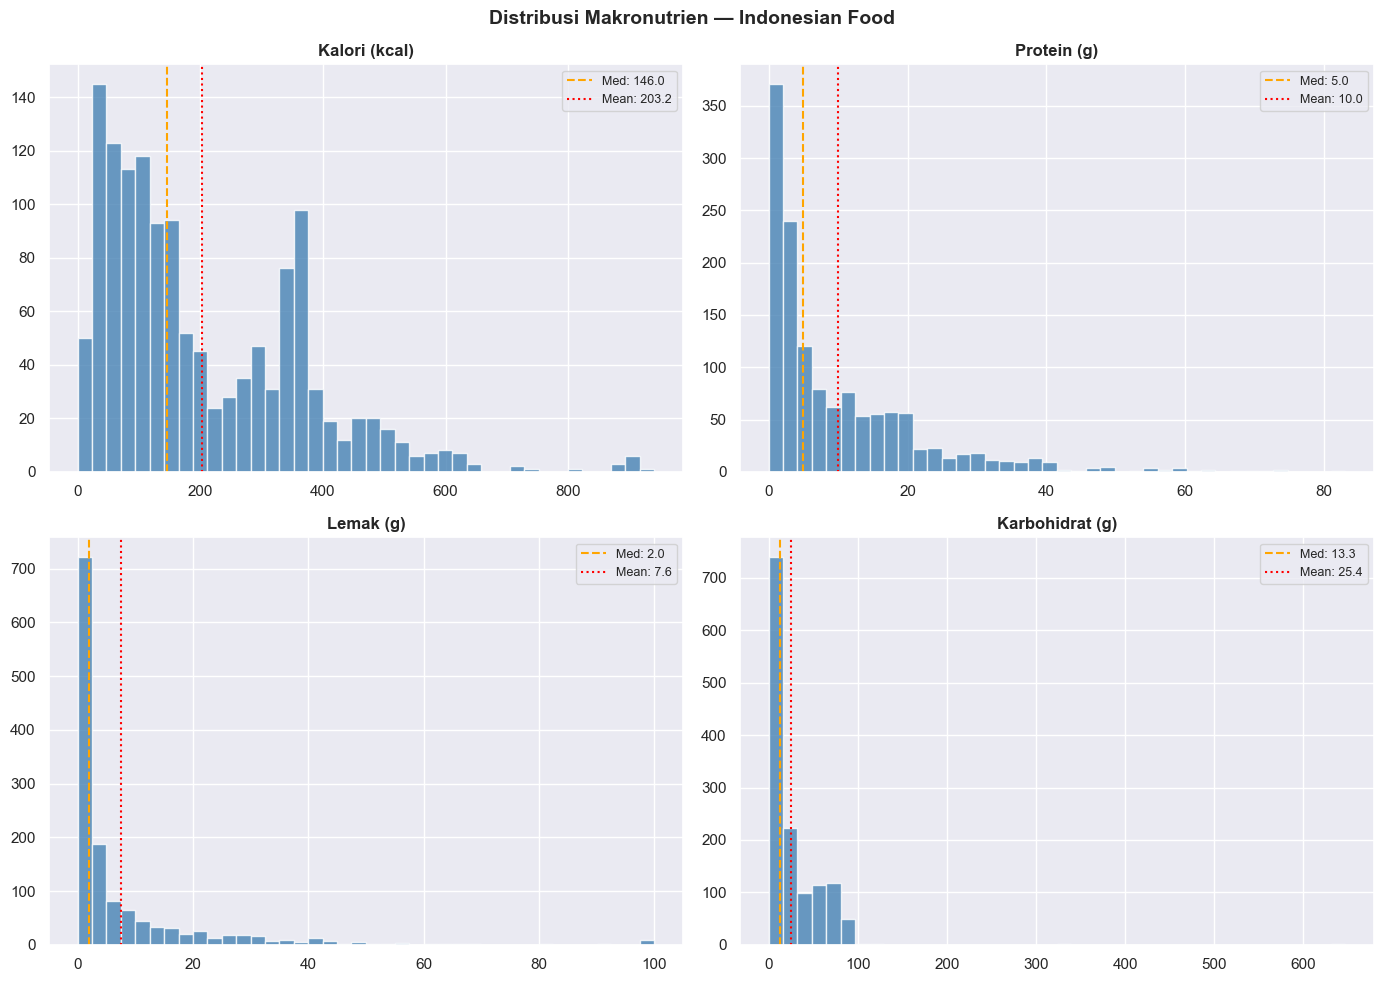

In [3]:
# ── Distribusi Makro ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
macro_cols = {'calories':'Kalori (kcal)', 'proteins':'Protein (g)',
              'fat':'Lemak (g)', 'carbohydrate':'Karbohidrat (g)'}

for ax, (col, label) in zip(axes.flatten(), macro_cols.items()):
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='orange', linestyle='--', label=f'Med: {data.median():.1f}')
    ax.axvline(data.mean(), color='red', linestyle=':', label=f'Mean: {data.mean():.1f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Distribusi Makronutrien — Indonesian Food', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/eda/macro_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# ── 0-Kalori Detection ──
zero_cal = df[df['calories'] == 0]
print(f'Entri 0 kalori: {len(zero_cal)} ({len(zero_cal)/len(df)*100:.1f}%)')
print('Sample (akan diimpute ke 1 di preprocessing):')
print(zero_cal[['name','calories','proteins','fat','carbohydrate']].head(10))

Entri 0 kalori: 1 (0.1%)
Sample (akan diimpute ke 1 di preprocessing):
        name  calories  proteins  fat  carbohydrate
2  Agar-agar       0.0       0.0  0.2           0.0


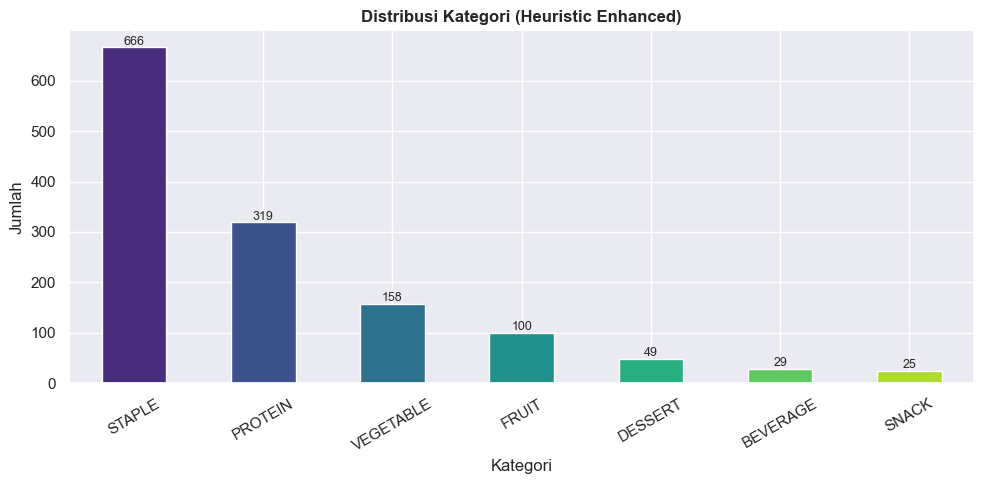

category_guess
STAPLE       666
PROTEIN      319
VEGETABLE    158
FRUIT        100
DESSERT       49
BEVERAGE      29
SNACK         25
Name: count, dtype: int64


In [4]:
# ── Kategorisasi Heuristic (Enhanced) ──
# Keyword dictionary 3x lebih kaya dari paper IPB Jurnal Keteknikan 2024
KEYWORDS = {
    'PROTEIN':    ['ayam','sapi','ikan','telur','tahu','tempe','daging','udang','cumi',
                   'bebek','kambing','lele','bandeng','gurame','salmon','tuna','bakso',
                   'keju','sosis ayam','kornet','sarden','ati','hati','jerohan'],
    'VEGETABLE':  ['sayur','bayam','kangkung','brokoli','wortel','sawi','kol','daun',
                   'buncis','kubis','terong','labu','timun','selada','bawang','tomat',
                   'gado-gado','urap','pecel','asinan','karedok','lalap'],
    'FRUIT':      ['buah','apel','mangga','pisang','jeruk','semangka','anggur','pepaya',
                   'salak','melon','nanas','alpukat','lemon','jambu','rambutan','duku',
                   'durian','mangosteen','manggis','kelengkeng','sirsak','markisa'],
    'BEVERAGE':   ['minum','teh','kopi','jus','susu','air ','minuman','sirup','soda',
                   'es teh','es jeruk','cappuccino','latte','smoothie','milkshake',
                   'wedang','jamu','bandrek','sekoteng','cendol'],
    'DESSERT':    ['kue','puding','es krim','dodol','klepon','bakpia','cake','martabak',
                   'brownie','coklat','permen','gulali','halua','tart','onde','getuk',
                   'wajik','lemper','lapis','bika ambon'],
    'SNACK':      ['keripik','biskuit','kerupuk','nugget','sosis','chiki','crackers',
                   'gorengan','bakwan','pisang goreng','singkong goreng','tahu isi'],
    'STAPLE':     ['nasi','mie','kentang','jagung','roti','pasta','ubi','singkong',
                   'bihun','ketupat','lontong','bubur','oatmeal','sereal','spaghetti'],
}

def categorize(name):
    n = str(name).lower()
    for cat in ['PROTEIN','VEGETABLE','FRUIT','BEVERAGE','DESSERT','SNACK','STAPLE']:
        if any(kw in n for kw in KEYWORDS[cat]):
            return cat
    return 'STAPLE'  # Default

df['category_guess'] = df['name'].apply(categorize)
cat_counts = df['category_guess'].value_counts()

plt.figure(figsize=(10, 5))
cat_counts.plot(kind='bar', color=sns.color_palette('viridis', len(cat_counts)))
plt.title('Distribusi Kategori (Heuristic Enhanced)', fontweight='bold')
plt.xlabel('Kategori'); plt.ylabel('Jumlah')
plt.xticks(rotation=30)
for i, v in enumerate(cat_counts.values):
    plt.text(i, v+5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('output/eda/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(cat_counts)

In [5]:
# ── Cuisine Clustering (Padang/Jawa/Sunda/Asian/Western) ──
CUISINE_KEYWORDS = {
    'PADANG':   ['rendang','dendeng','sate padang','gulai','kalio','lemang','sambal lado',
                  'gajeboh','asam pedas','pangek'],
    'JAVA':     ['gudeg','soto','rawon','nasi pecel','tumpeng','wedang','klepon','onde',
                  'getuk','tahu petis','rujak cingur','lontong balap'],
    'SUNDA':    ['karedok','lalap','nasi tutug','nasi liwet','batagor','siomay','pepes',
                  'sayur asem','ulukutek'],
    'ASIAN':    ['ramen','sushi','dimsum','siomay','bakpao','mie ayam','kwetiau','nasi goreng'],
    'WESTERN':  ['burger','pizza','steak','spaghetti','sandwich','pasta','french fries']
}

def guess_cuisine(name):
    n = str(name).lower()
    for cuisine, kws in CUISINE_KEYWORDS.items():
        if any(kw in n for kw in kws):
            return cuisine
    return 'GENERAL_INDO'  # Default Indonesian

df['cuisine_guess'] = df['name'].apply(guess_cuisine)
cuisine_counts = df['cuisine_guess'].value_counts()

print('Distribusi cuisine (heuristic):')
print(cuisine_counts)

Distribusi cuisine (heuristic):
cuisine_guess
GENERAL_INDO    1282
PADANG            27
JAVA              24
SUNDA              8
WESTERN            3
ASIAN              2
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_7956\1084326748.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category_guess', y='est_price_idr', palette='viridis', ax=ax)


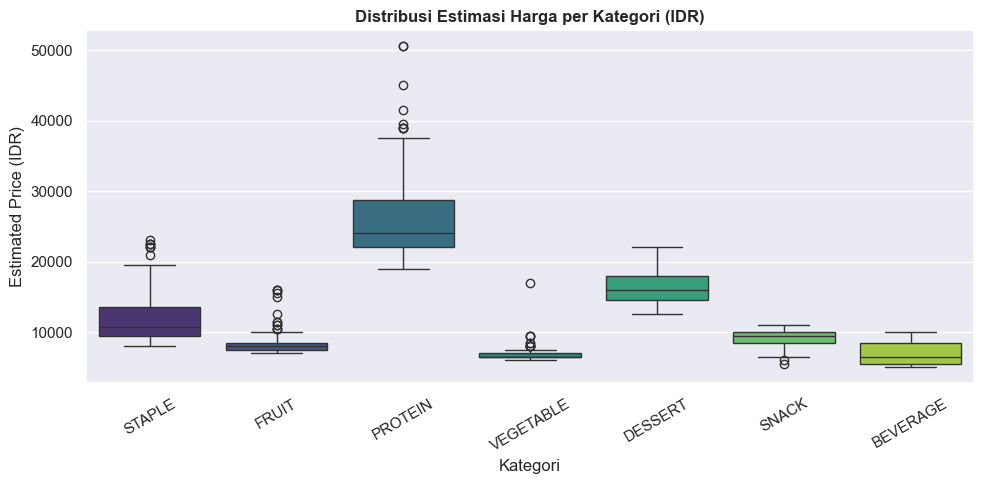

Harga per kategori:
                count     mean     std      min      25%      50%      75%  \
category_guess                                                               
BEVERAGE         29.0   7052.0  1549.0   5000.0   5500.0   6500.0   8500.0   
DESSERT          49.0  16316.0  2157.0  12500.0  14500.0  16000.0  18000.0   
FRUIT           100.0   8670.0  1918.0   7000.0   7500.0   8000.0   8500.0   
PROTEIN         319.0  25745.0  5265.0  19000.0  22000.0  24000.0  28750.0   
SNACK            25.0   9040.0  1399.0   5500.0   8500.0   9500.0  10000.0   
STAPLE          666.0  11634.0  2680.0   8000.0   9500.0  10750.0  13500.0   
VEGETABLE       158.0   6791.0  1018.0   6000.0   6500.0   6500.0   7000.0   

                    max  
category_guess           
BEVERAGE        10000.0  
DESSERT         22000.0  
FRUIT           16000.0  
PROTEIN         50500.0  
SNACK           11000.0  
STAPLE          23000.0  
VEGETABLE       17000.0  


In [6]:
# ── Heuristic Price Validation ──
BASE_PRICE = {
    'STAPLE': 8000, 'PROTEIN': 18000, 'VEGETABLE': 6000, 'FRUIT': 7000,
    'BEVERAGE': 5000, 'DESSERT': 10000, 'SNACK': 5000
}

def estimate_price(row):
    base = BASE_PRICE.get(row['category_guess'], 7000)
    cal = max(row['calories'], 10)
    return round((base * (1 + cal / 500)) / 500) * 500

df['est_price_idr'] = df.apply(estimate_price, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='category_guess', y='est_price_idr', palette='viridis', ax=ax)
ax.set_title('Distribusi Estimasi Harga per Kategori (IDR)', fontweight='bold')
ax.set_xlabel('Kategori'); ax.set_ylabel('Estimated Price (IDR)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('output/eda/price_per_category.png', dpi=150)
plt.show()

print('Harga per kategori:')
print(df.groupby('category_guess')['est_price_idr'].describe().round(0))

In [7]:
# ── Diet Recommendations Dataset Exploration ──
try:
    df_diet = pd.read_csv(DIET_PATH)
    print(f'Diet dataset: {df_diet.shape}')
    print('Kolom:', list(df_diet.columns))
    
    print('\nDiet_Recommendation distribusi:')
    print(df_diet['Diet_Recommendation'].value_counts())
    print('\nDisease_Type distribusi:')
    print(df_diet['Disease_Type'].value_counts())
    
    # Cross-tab Disease vs Diet
    print('\nCross-tab Disease × Diet:')
    print(pd.crosstab(df_diet['Disease_Type'], df_diet['Diet_Recommendation']))
except Exception as e:
    print(f'Diet dataset error: {e}')

Diet dataset: (1000, 20)
Kolom: ['Patient_ID', 'Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'Disease_Type', 'Severity', 'Physical_Activity_Level', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Dietary_Restrictions', 'Allergies', 'Preferred_Cuisine', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score', 'Diet_Recommendation']

Diet_Recommendation distribusi:
Diet_Recommendation
Balanced      426
Low_Sodium    316
Low_Carb      258
Name: count, dtype: int64

Disease_Type distribusi:
Disease_Type
Hypertension    316
Diabetes        258
Obesity         222
Name: count, dtype: int64

Cross-tab Disease × Diet:
Diet_Recommendation  Balanced  Low_Carb  Low_Sodium
Disease_Type                                       
Diabetes                    0       258           0
Hypertension                0         0         316
Obesity                   222         0           0


In [8]:
# ── Save Summary ──
if 'cat_counts' not in locals():
    cat_counts = df['category_guess'].value_counts() if 'category_guess' in df.columns else pd.Series(dtype=int)
if 'cuisine_counts' not in locals():
    cuisine_counts = df['cuisine_guess'].value_counts() if 'cuisine_guess' in df.columns else pd.Series(dtype=int)

if 'category_guess' in df.columns and 'est_price_idr' in df.columns:
    price_summary = df.groupby('category_guess')['est_price_idr'].mean().round(0).to_dict()
else:
    price_summary = {}

summary = {
    'n_foods': len(df),
    'zero_calorie_count': int(len(zero_cal)),
    'calorie_range': f"{df['calories'].min()} – {df['calories'].max()}",
    'avg_calories': round(float(df['calories'].mean()), 1),
    'category_dist': cat_counts.to_dict(),
    'cuisine_dist': cuisine_counts.to_dict(),
    'price_summary_per_category': price_summary,
    'augmentation_columns_required': ['category', 'estimated_price_idr', 'is_halal',
                                       'is_vegetarian', 'is_vegan', 'is_gluten_free', 'cuisine'],
}
with open('output/eda/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ EDA selesai.')
print(json.dumps(summary, indent=2))

✅ EDA selesai.
{
  "n_foods": 1346,
  "zero_calorie_count": 1,
  "calorie_range": "0.0 \u2013 940.0",
  "avg_calories": 203.2,
  "category_dist": {
    "STAPLE": 666,
    "PROTEIN": 319,
    "VEGETABLE": 158,
    "FRUIT": 100,
    "DESSERT": 49,
    "BEVERAGE": 29,
    "SNACK": 25
  },
  "cuisine_dist": {
    "GENERAL_INDO": 1282,
    "PADANG": 27,
    "JAVA": 24,
    "SUNDA": 8,
    "WESTERN": 3,
    "ASIAN": 2
  },
  "price_summary_per_category": {
    "BEVERAGE": 7052.0,
    "DESSERT": 16316.0,
    "FRUIT": 8670.0,
    "PROTEIN": 25745.0,
    "SNACK": 9040.0,
    "STAPLE": 11634.0,
    "VEGETABLE": 6791.0
  },
  "augmentation_columns_required": [
    "category",
    "estimated_price_idr",
    "is_halal",
    "is_vegetarian",
    "is_vegan",
    "is_gluten_free",
    "cuisine"
  ]
}
